# 🌿 VedaVision — Module 2
# Notebook 04 — Feature Extraction
### Input: augmented_final/ → Output: csv/

---

**Input**  : `dataset/augmented_final/species_name/top/*.jpg`  
             `dataset/augmented_final/species_name/bottom/*.jpg`

**Output** : `dataset/csv/species_id_train_features.csv`  
             `dataset/csv/species_id_test_features.csv`  
             `dataset/csv/species_id_test_labels.csv`

---

### Features Extracted:
```
1. GLCM          →  6 texture features
                    (contrast, dissimilarity, homogeneity,
                     energy, correlation, ASM)

2. Gabor         → 40 frequency features
                    (5 frequencies × 4 orientations × mean+std)

3. HOG           →  5 shape/edge features
                    (mean, std, max, min, sum)

4. Hu-moments    →  7 shape descriptor features
                    (log-transformed, rotation invariant)

5. HSV Color     →  6 color features
                    (hue, saturation, value — mean + std)

6. Contour Shape →  7 geometric features
                    (area, perimeter, aspect ratio, extent,
                     solidity, circularity, equivalent diameter)

7. LBP           → 26 local texture features
                    (Local Binary Pattern histogram)
─────────────────────────────────────────────
   TOTAL         → 97 features per image
```
---

## Cell 1 — Install Libraries

In [7]:
!pip install opencv-python-headless scikit-image matplotlib numpy tqdm pandas -q
print('✅ Libraries installed!')

✅ Libraries installed!


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\User\\Documents\\Projects\\Veda_Vision\\ayurveda-recognition\\venv\\Lib\\site-packages\\cv2\\cv2.pyd'
Check the permissions.



## Cell 2 — Import Libraries

In [18]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from glob import glob
from tqdm import tqdm
from skimage.feature import graycomatrix, graycoprops, hog, local_binary_pattern
from skimage.filters import gabor

print('✅ All libraries imported!')

✅ All libraries imported!


## Cell 3 — Mount Drive & Configure Paths
**Only change things in this cell**

In [24]:

AUGMENTED_FINAL = 'C:/Users/User/Documents/UOM/L4S2/Research/augmented_final'
RAW_PATH        = 'C:/Users/User/Documents/UOM/L4S2/Research'   # original test images
CSV_PATH        = 'C:/Users/User/Documents/UOM/L4S2/Research/csv'
LOGS_PATH       = 'C:/Users/User/Documents/UOM/L4S2/Research/logs'

VIEWS           = ['top', 'bottom']   # must match augmentation notebook
IMG_EXTENSIONS  = ('.jpg', '.jpeg', '.png')
# ============================================================

os.makedirs(CSV_PATH,  exist_ok=True)
os.makedirs(LOGS_PATH, exist_ok=True)

# Get all species (skip hidden folders)
species_list = sorted([
    d for d in os.listdir(AUGMENTED_FINAL)
    if os.path.isdir(os.path.join(AUGMENTED_FINAL, d))
    and not d.startswith('.')
])

 
print(f'📁 Input  (Augmented) : {AUGMENTED_FINAL}')
print(f'📁 Output (CSV)       : {CSV_PATH}')
print(f'👁️  Views              : {VIEWS}')
print(f'🌿 Species found      : {species_list}')

📁 Input  (Augmented) : C:/Users/User/Documents/UOM/L4S2/Research/augmented_final
📁 Output (CSV)       : C:/Users/User/Documents/UOM/L4S2/Research/csv
👁️  Views              : ['top', 'bottom']
🌿 Species found      : ['Diya_Na', 'Gammiris', 'Ingini', 'Iriveriya', 'Kapparawalliya', 'Kora_Kaha', 'Kuringchan', 'Kurundu', 'Masbadda', 'Na', 'Rathu_Koboleela', 'Sudu_Koboleela', 'Wali_Kaha']


## Cell 4 — Helper Functions

In [20]:
def get_images(base_path, species, view):
    """Get all images for a species/view combination."""
    return (
        glob(os.path.join(base_path, species, view, '*.jpg'))  +
        glob(os.path.join(base_path, species, view, '*.jpeg')) +
        glob(os.path.join(base_path, species, view, '*.png'))
    )

def bgr2rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def bgr2gray(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print('✅ Helper functions defined!')

✅ Helper functions defined!


## Cell 5 — Define All Feature Extraction Functions

| Feature Group | What it Captures | Features |
|---|---|---|
| **GLCM** | Vein texture patterns | 6 |
| **Gabor** | Vein frequency & direction | 40 |
| **HOG** | Leaf shape & edges | 5 |
| **Hu-moments** | Overall leaf shape | 7 |
| **HSV Color** | Leaf colour shade | 6 |
| **Contour Shape** | Geometric properties | 7 |
| **LBP** | Local surface texture | 26 |
| **Total** | | **97** |

In [25]:
# ============================================================
# FEATURE EXTRACTION FUNCTIONS
# ============================================================

# ── 1. GLCM — Texture Features ────────────────────────────
def extract_glcm(gray_img):
    """
    Gray-Level Co-occurrence Matrix (GLCM).
    Captures HOW PIXELS RELATE to their neighbours.
    Why for leaves:
    → Gotukola has rough bumpy venation → high contrast GLCM
    → Long narrow leaf has smooth parallel texture → low contrast
    → Different species have measurably different texture values
    Returns 6 values: contrast, dissimilarity, homogeneity,
                      energy, correlation, ASM
    """
    distances  = [1, 2, 3, 4]
    angles     = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    properties = ['contrast', 'dissimilarity', 'homogeneity',
                  'energy', 'correlation', 'ASM']
    glcm = graycomatrix(
        gray_img, distances=distances, angles=angles,
        levels=256, symmetric=True, normed=True)
    features = {}
    for prop in properties:
        features[f'glcm_{prop}'] = graycoprops(glcm, prop).mean()
    return features  # 6 values


# ── 2. Gabor — Vein Frequency Features ────────────────────
def extract_gabor(gray_img):
    """
    Gabor filter bank responses.
    Captures TEXTURE at different FREQUENCIES and ORIENTATIONS.
    Why for leaves:
    → Long narrow leaves have veins running vertically
      → Gabor captures horizontal frequency response
    → Gotukola has fan-shaped radiating veins
      → Gabor captures multiple direction responses
    → Different vein patterns = different Gabor values
    Returns 40 values: 5 freq × 4 orientations × (mean + std)
    """
    frequencies  = [0.1, 0.2, 0.3, 0.4, 0.5]
    orientations = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    img_float    = gray_img.astype(np.float32) / 255.0
    features     = {}
    for fi, freq in enumerate(frequencies):
        for ti, theta in enumerate(orientations):
            real, _ = gabor(img_float, frequency=freq, theta=theta)
            features[f'gabor_f{fi}_t{ti}_mean'] = real.mean()
            features[f'gabor_f{fi}_t{ti}_std']  = real.std()
    return features  # 40 values


# ── 3. HOG — Shape & Edge Features ────────────────────────
def extract_hog(gray_img):
    """
    Histogram of Oriented Gradients (HOG).
    Captures DIRECTION of edges across the image.
    Why for leaves:
    → Long narrow leaf: edges run vertically → high vertical HOG
    → Round leaf: edges curve in all directions → spread HOG
    → Gotukola fan shape: distinct HOG pattern
    → Most powerful for distinguishing different leaf SHAPES
    Returns 5 summary values: mean, std, max, min, sum
    """
    hog_feats, _ = hog(
        gray_img,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        visualize=True,
        feature_vector=True)
    return {
        'hog_mean': hog_feats.mean(),
        'hog_std' : hog_feats.std(),
        'hog_max' : hog_feats.max(),
        'hog_min' : hog_feats.min(),
        'hog_sum' : hog_feats.sum()
    }  # 5 values


# ── 4. Hu-Moments — Shape Descriptor Features ─────────────
def extract_hu_moments(gray_img):
    """
    Hu-Moments — 7 rotation/scale invariant shape descriptors.
    Captures OVERALL SHAPE of the leaf as numbers.
    Why for leaves:
    → Long narrow leaf → high Hu values (elongated)
    → Round leaf → low Hu values (circular)
    → Gotukola fan → medium unique Hu pattern
    Log-transformed for numerical stability.
    Returns 7 values.
    """
    moments    = cv2.moments(gray_img)
    hu         = cv2.HuMoments(moments).flatten()
    hu_log     = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)
    return {f'hu_{i+1}': v for i, v in enumerate(hu_log)}  # 7 values


# ── 5. HSV Color Features ─────────────────────────────────
def extract_hsv_color(image_bgr):
    """
    HSV color channel statistics on leaf pixels only.
    H = Hue (what color) — not affected by shadow ✅
    S = Saturation (how vivid the green)
    V = Value (brightness)
    Why for leaves:
    → Different species have subtle green shade differences
    → HSV more reliable than RGB under different lighting
    → Shadow does NOT change Hue — stays consistent ✅
    → Critical for health assessment (yellowing = low S, high H)
    Applies mask to use LEAF PIXELS ONLY (not white background).
    Returns 6 values: H mean/std, S mean/std, V mean/std
    """
    hsv  = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    mask = (gray < 250).astype(np.uint8)  # exclude white background
    h, s, v = cv2.split(hsv)
    features = {}
    for name, ch in [('h', h), ('s', s), ('v', v)]:
        pixels = ch[mask > 0]
        if len(pixels) > 0:
            features[f'hsv_{name}_mean'] = float(pixels.mean())
            features[f'hsv_{name}_std']  = float(pixels.std())
        else:
            features[f'hsv_{name}_mean'] = 0.0
            features[f'hsv_{name}_std']  = 0.0
    return features  # 6 values


# ── 6. Contour Shape Features ─────────────────────────────
def extract_contour_shape(gray_img):
    """
    Geometric shape features from leaf contour.
    Why for leaves:
    → Aspect ratio: long narrow (high) vs round (near 1.0)
    → Circularity: how circular is the leaf
    → Solidity: how solid/compact vs lobed/notched
    → Most useful for separating morphologically similar species
       that differ mainly in shape ratios ✅
    Returns 7 values:
    area, perimeter, aspect_ratio, extent,
    solidity, circularity, equiv_diameter
    """
    _, thresh = cv2.threshold(
        gray_img, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return {k: 0.0 for k in [
            'shape_area', 'shape_perimeter', 'shape_aspect_ratio',
            'shape_extent', 'shape_solidity',
            'shape_circularity', 'shape_equiv_diameter']}

    cnt  = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    peri = cv2.arcLength(cnt, True)
    x, y, w, h = cv2.boundingRect(cnt)
    hull        = cv2.convexHull(cnt)
    hull_area   = cv2.contourArea(hull)

    aspect_ratio   = float(w) / h if h > 0 else 0
    extent         = area / (w * h) if (w * h) > 0 else 0
    solidity       = area / hull_area if hull_area > 0 else 0
    circularity    = (4 * np.pi * area / (peri ** 2)
                      if peri > 0 else 0)
    equiv_diameter = np.sqrt(4 * area / np.pi) if area > 0 else 0

    return {
        'shape_area'          : area,
        'shape_perimeter'     : peri,
        'shape_aspect_ratio'  : aspect_ratio,
        'shape_extent'        : extent,
        'shape_solidity'      : solidity,
        'shape_circularity'   : circularity,
        'shape_equiv_diameter': equiv_diameter
    }  # 7 values


# ── 7. LBP — Local Binary Pattern ─────────────────────────
def extract_lbp(gray_img):
    """
    Local Binary Pattern (LBP) — local surface texture.
    Captures micro-texture patterns around each pixel.
    Why for leaves:
    → Gotukola has very rough bumpy surface texture
    → Long narrow leaves have smooth parallel texture
    → Dark oval leaf has very smooth waxy texture
    → LBP captures these micro-texture differences ✅
    → Very useful for morphologically similar leaves
       that differ in surface texture not shape
    Returns 26 histogram values.
    """
    radius   = 3
    n_points = 8 * radius
    lbp      = local_binary_pattern(
        gray_img, n_points, radius, method='uniform')
    hist, _  = np.histogram(
        lbp.ravel(),
        bins=n_points + 2,
        range=(0, n_points + 2))
    hist     = hist.astype(float)
    hist    /= (hist.sum() + 1e-7)  # normalize
    return {f'lbp_{i}': v for i, v in enumerate(hist)}  # 26 values

def get_leaf_mask_and_contour(image_bgr):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    mask = (gray < 245).astype(np.uint8) * 255
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return mask, None
    cnt = max(contours, key=cv2.contourArea)
    clean = np.zeros_like(mask)
    cv2.drawContours(clean, [cnt], -1, 255, cv2.FILLED)
    return clean, cnt


def extract_notch_features(cnt, leaf_length, min_defect_depth_px=3):
    hull_idx = cv2.convexHull(cnt, returnPoints=False)
    if len(hull_idx) < 4:
        return {'notch_depth': 0.0, 'notch_angle': 180.0}
    try:
        defects = cv2.convexityDefects(cnt, hull_idx)
    except cv2.error:
        return {'notch_depth': 0.0, 'notch_angle': 180.0}
    if defects is None:
        return {'notch_depth': 0.0, 'notch_angle': 180.0}

    defects = defects.reshape(-1, 4)
    deepest = max(defects, key=lambda d: d[3])
    s, e, f, depth = deepest
    depth_px = depth / 256.0
    if depth_px < min_defect_depth_px:
        return {'notch_depth': 0.0, 'notch_angle': 180.0}

    start, end, far = cnt[s][0], cnt[e][0], cnt[f][0]
    v1, v2 = start - far, end - far
    cos_ang = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-6)
    angle = np.degrees(np.arccos(np.clip(cos_ang, -1, 1)))

    return {
        'notch_depth': depth_px / max(leaf_length, 1),
        'notch_angle': angle,
    }


def extract_margin_features(cnt, area, peri, defect_depth_thresh_px=4):
    margin_roughness = (peri ** 2) / (4 * np.pi * area) if area > 0 else 0

    hull_idx = cv2.convexHull(cnt, returnPoints=False)
    serration_count = 0
    if len(hull_idx) >= 4:
        try:
            defects = cv2.convexityDefects(cnt, hull_idx)
            if defects is not None:
                defects = defects.reshape(-1, 4)
                depths_px = defects[:, 3] / 256.0
                serration_count = int((depths_px > defect_depth_thresh_px).sum())
        except cv2.error:
            pass

    return {
        'margin_roughness': margin_roughness,
        'serration_count': serration_count,
    }

def extract_principal_axis_features(cnt):
    """
    Length/width measured along the leaf's own principal axis (via PCA
    on the contour points), not the image's bounding box.

    Why: a bounding-box aspect ratio changes if the leaf is even
    slightly rotated in-frame; the principal axis doesn't. More
    accurate version of shape_aspect_ratio for a real, imperfectly
    aligned photo. Useful across most pairs since elongation was a
    strong discriminator in nearly every one measured (e.g. Diya NA
    4.93 vs Na 3.62; Walikaha 2.27 vs Kora kaha 1.84).
    """
    points = cnt.reshape(-1, 2).astype(np.float32)
    mean, eigvecs, eigvals = cv2.PCACompute2(points, mean=None)
    projected = (points - mean) @ eigvecs.T
    length = projected[:, 0].max() - projected[:, 0].min()
    width = projected[:, 1].max() - projected[:, 1].min()
    ratio = length / width if width > 0 else 0
    return {
        'principal_length': length,
        'principal_width': width,
        'principal_aspect_ratio': ratio,
    }


def extract_vein_edge_density(gray_img, mask):
    """
    Canny-edge density within the leaf, as a direct vein-visibility
    proxy -- distinct from GLCM/LBP (which measure general texture
    statistics, not specifically linear vein structure).

    Why: measured directly -- e.g. Kora kaha (smooth, glossy) at 11.6
    vs Walikaha (visibly veined/textured) at 34.1 -- one of the largest
    gaps found in this whole analysis. Also separates Diya NA (18.5)
    from Na (28.5) clearly.
    """
    edges = cv2.Canny(gray_img, 40, 120)
    leaf_px = mask > 0
    total = leaf_px.sum()
    if total == 0:
        return {'vein_edge_density': 0.0}
    density = (edges[leaf_px] > 0).sum() / total * 100
    return {'vein_edge_density': density}


# ── Master function — extract ALL features ─────────────────
def extract_all_features(image_bgr):
    """
    Extract all 105 features from one image (97 generic + 8 handcrafted).
    Input : BGR image array (preprocessed, 224×224)
    Output: dict with 105 feature key-value pairs
    """
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    leaf_mask = (gray < 250).astype(np.uint8)
    coords = cv2.findNonZero(leaf_mask)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        gray_for_texture = gray[y:y+h, x:x+w]
    else:
        gray_for_texture = gray

    features = {}
    features.update(extract_glcm(gray_for_texture))            #  6 features
    features.update(extract_gabor(gray_for_texture))            # 40 features
    features.update(extract_hog(gray_for_texture))              #  5 features
    features.update(extract_hu_moments(gray))       #  7 features
    features.update(extract_hsv_color(image_bgr))   #  6 features
    features.update(extract_contour_shape(gray))    #  7 features
    features.update(extract_lbp(gray_for_texture))              # 26 features

    # ── Handcrafted (botanically-informed) features ────────
    mask, cnt = get_leaf_mask_and_contour(image_bgr)
    if cnt is not None:
        area = cv2.contourArea(cnt)
        peri = cv2.arcLength(cnt, True)
        x, y, w, h = cv2.boundingRect(cnt)
        leaf_length = max(w, h)

        features.update(extract_notch_features(cnt, leaf_length))   # 2 features
        features.update(extract_margin_features(cnt, area, peri))   # 2 features
        features.update(extract_principal_axis_features(cnt))       # 3 features
        features.update(extract_vein_edge_density(gray, mask))      # 1 feature
    else:
        # Segmentation failed on this image (e.g. bad crop/coverage) —
        # fall back to neutral defaults so the row isn't dropped entirely
        features.update({
            'notch_depth': 0.0, 'notch_angle': 180.0,
            'margin_roughness': 0.0, 'serration_count': 0,
            'principal_length': 0.0, 'principal_width': 0.0,
            'principal_aspect_ratio': 0.0, 'vein_edge_density': 0.0,
        })

    return features  # 105 total


print('✅ All feature extraction functions defined!')
print()
print('   Feature Group      Features   What it captures')
print('   ────────────────────────────────────────────────────')
print('   GLCM                  6        Vein texture patterns')
print('   Gabor                40        Vein frequency & direction')
print('   HOG                   5        Leaf shape & edges')
print('   Hu-moments            7        Overall leaf shape')
print('   HSV Color             6        Leaf colour shade')
print('   Contour Shape         7        Geometric properties')
print('   LBP                  26        Local surface texture')
print('   Handcrafted (notch,')
print('   margin, axis, vein)   8        Botanically-targeted features')
print('   ────────────────────────────────────────────────────')
print('   TOTAL                105       features per image')

✅ All feature extraction functions defined!

   Feature Group      Features   What it captures
   ────────────────────────────────────────────────────
   GLCM                  6        Vein texture patterns
   Gabor                40        Vein frequency & direction
   HOG                   5        Leaf shape & edges
   Hu-moments            7        Overall leaf shape
   HSV Color             6        Leaf colour shade
   Contour Shape         7        Geometric properties
   LBP                  26        Local surface texture
   Handcrafted (notch,
   margin, axis, vein)   8        Botanically-targeted features
   ────────────────────────────────────────────────────
   TOTAL                105       features per image


## Cell 6 — Test Feature Extraction on ONE Image
### Shows feature values and visualizes what each method captures

In [15]:
# Pick one sample image to test
import os

sample_path = r'C:\Users\User\Documents\UOM\L4S2\Research\augmented_final\Sudu_Koboleela\top\top (1)_pre_bright_down.jpg'

print("Path exists:", os.path.exists(sample_path))
print("Path:", sample_path)
sample_species = species_list[0]
sample_view    = VIEWS[0]
sample_imgs    = get_images(AUGMENTED_FINAL, sample_species, sample_view)

if not sample_imgs:
    print(f'⚠️  No images found for {sample_species}/{sample_view}')
    print(f'   Check AUGMENTED_FINAL path in Cell 3!')
else:
    sample_path ="C:/Users/User/Documents/UOM/L4S2/Research/augmented_final/Sudu_Koboleela/top/ top (1)_pre_bright_down.jpg"
    sample_bgr  = cv2.imread(sample_path)
    sample_gray = cv2.cvtColor(sample_bgr, cv2.COLOR_BGR2GRAY)

    # Extract all features
    all_feats = extract_all_features(sample_bgr)

    print(f'✅ Feature extraction test on: {sample_species}/{sample_view}')
    print(f'   Image: {os.path.basename(sample_path)}')
    print(f'   Total features extracted: {len(all_feats)}')
    print()
    print('   Sample values:')
    print(f'   glcm_contrast      = {all_feats["glcm_contrast"]:.4f}')
    print(f'   glcm_energy        = {all_feats["glcm_energy"]:.4f}')
    print(f'   hog_mean           = {all_feats["hog_mean"]:.4f}')
    print(f'   hu_1               = {all_feats["hu_1"]:.4f}')
    print(f'   hsv_h_mean         = {all_feats["hsv_h_mean"]:.4f}')
    print(f'   shape_aspect_ratio = {all_feats["shape_aspect_ratio"]:.4f}')
    print(f'   shape_circularity  = {all_feats["shape_circularity"]:.4f}')

Path exists: False
Path: C:\Users\User\Documents\UOM\L4S2\Research\augmented_final\Sudu_Koboleela\top\top (1)_pre_bright_down.jpg


error: OpenCV(5.0.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


## Cell 7 — Visualize What Each Feature Captures
### Shows original leaf + HOG visualization + LBP visualization

C:\Users\User\AppData\Local\Temp\ipykernel_8808\4292119369.py:82: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_8808\4292119369.py:83: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{LOGS_PATH}/04_feature_visualization.png',
c:\Users\User\Documents\Projects\Veda_Vision\ayurveda-recognition\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


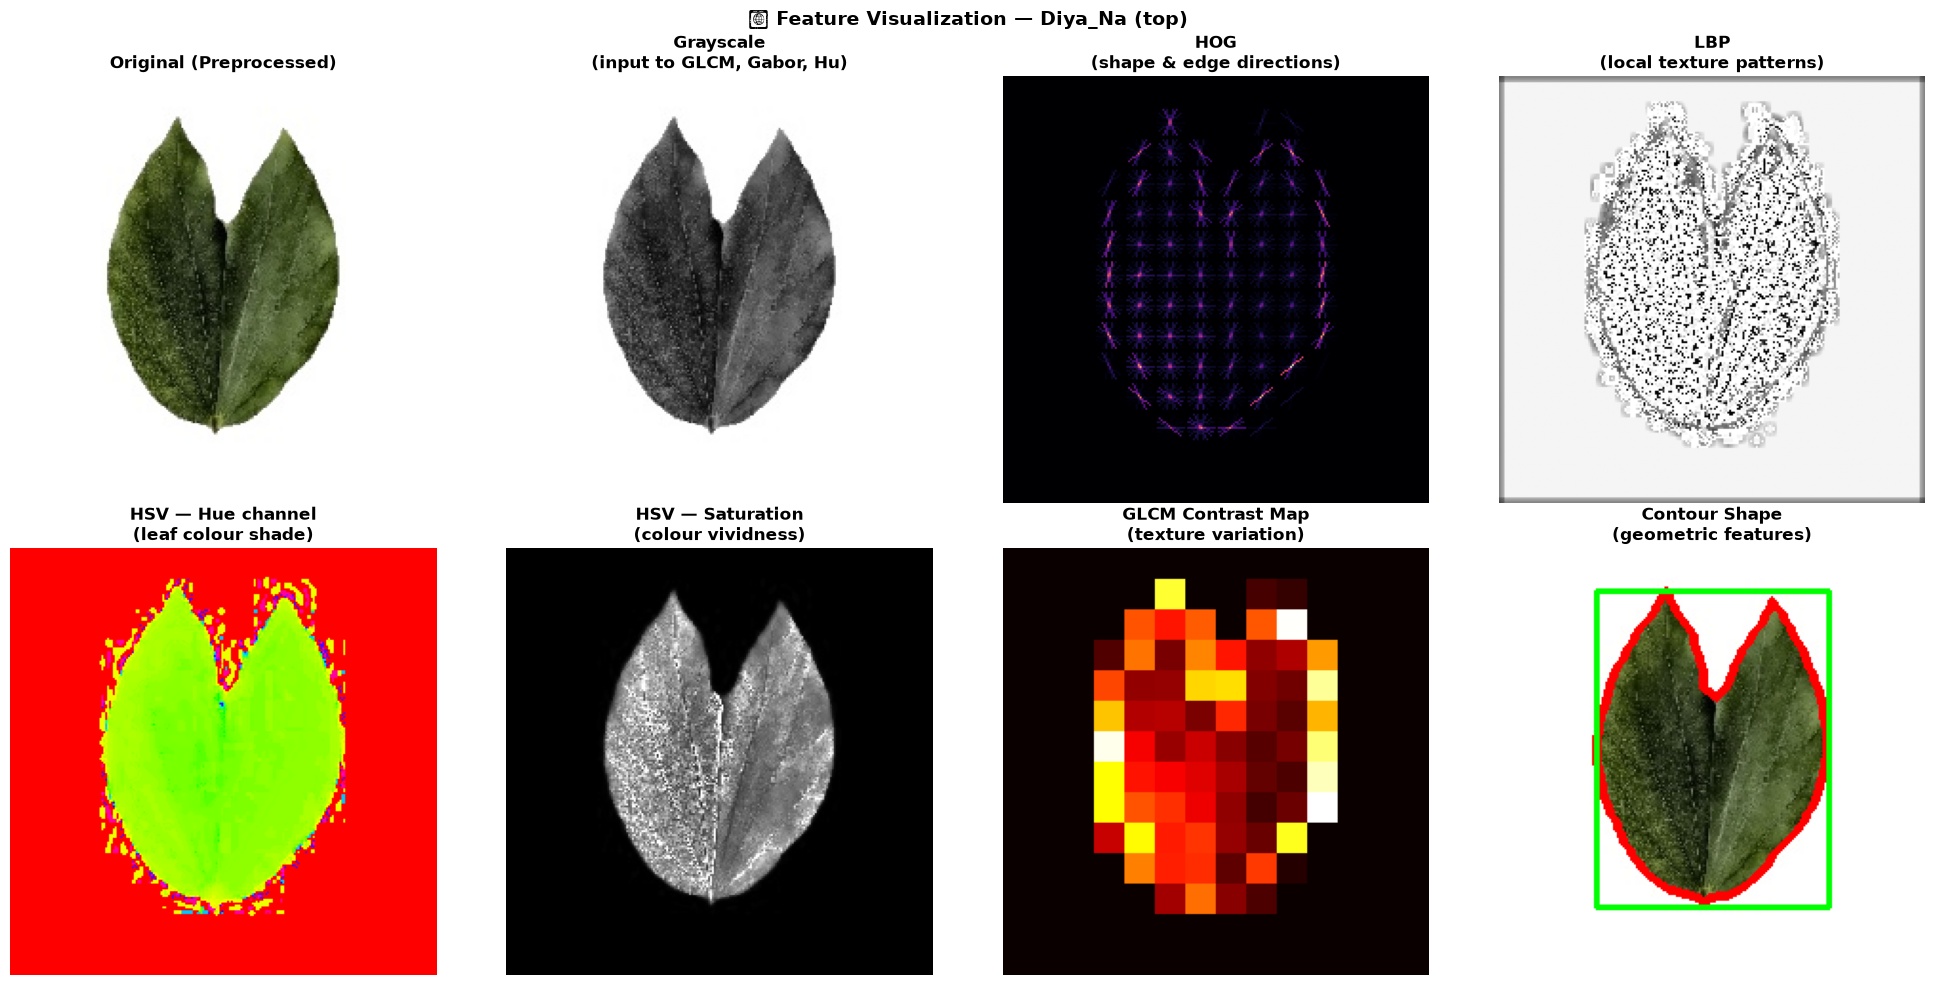

✅ Feature visualization saved!


In [8]:
from skimage.feature import hog as sk_hog
from skimage.feature import local_binary_pattern

# ── Generate visualizations ────────────────────────────────
_, hog_image = sk_hog(
    sample_gray,
    orientations=9,
    pixels_per_cell=(16, 16),
    cells_per_block=(2, 2),
    visualize=True,
    feature_vector=True)

lbp_image = local_binary_pattern(
    sample_gray, 24, 3, method='uniform')

hsv_image = cv2.cvtColor(sample_bgr, cv2.COLOR_BGR2HSV)

# ── Display all visualizations ─────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(
    f'🔬 Feature Visualization — {sample_species} ({sample_view})',
    fontsize=14, fontweight='bold')

axes[0][0].imshow(bgr2rgb(sample_bgr))
axes[0][0].set_title('Original (Preprocessed)', fontweight='bold')
axes[0][0].axis('off')

axes[0][1].imshow(sample_gray, cmap='gray')
axes[0][1].set_title('Grayscale\n(input to GLCM, Gabor, Hu)', fontweight='bold')
axes[0][1].axis('off')

axes[0][2].imshow(hog_image, cmap='magma')
axes[0][2].set_title('HOG\n(shape & edge directions)', fontweight='bold')
axes[0][2].axis('off')

axes[0][3].imshow(lbp_image, cmap='gray')
axes[0][3].set_title('LBP\n(local texture patterns)', fontweight='bold')
axes[0][3].axis('off')

axes[1][0].imshow(hsv_image[:,:,0], cmap='hsv')
axes[1][0].set_title('HSV — Hue channel\n(leaf colour shade)', fontweight='bold')
axes[1][0].axis('off')

axes[1][1].imshow(hsv_image[:,:,1], cmap='gray')
axes[1][1].set_title('HSV — Saturation\n(colour vividness)', fontweight='bold')
axes[1][1].axis('off')

# GLCM — show contrast map
from skimage.feature import graycomatrix, graycoprops
glcm_vis = np.zeros_like(sample_gray, dtype=np.float32)
h, w = sample_gray.shape
step = 16
for y in range(0, h - step, step):
    for x in range(0, w - step, step):
        patch  = sample_gray[y:y+step, x:x+step]
        g      = graycomatrix(patch, [1], [0],
                              levels=256,
                              symmetric=True, normed=True)
        contrast = graycoprops(g, 'contrast')[0, 0]
        glcm_vis[y:y+step, x:x+step] = contrast
axes[1][2].imshow(glcm_vis, cmap='hot')
axes[1][2].set_title('GLCM Contrast Map\n(texture variation)', fontweight='bold')
axes[1][2].axis('off')

# Contour shape
_, thresh = cv2.threshold(
    sample_gray, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
contours, _ = cv2.findContours(
    thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contour_img = bgr2rgb(sample_bgr.copy())
if contours:
    cnt = max(contours, key=cv2.contourArea)
    cv2.drawContours(contour_img, [cnt], -1, (255, 0, 0), 3)
    x, y, bw, bh = cv2.boundingRect(cnt)
    cv2.rectangle(contour_img, (x, y),
                  (x+bw, y+bh), (0, 255, 0), 2)
axes[1][3].imshow(contour_img)
axes[1][3].set_title('Contour Shape\n(geometric features)', fontweight='bold')
axes[1][3].axis('off')

plt.tight_layout()
plt.savefig(f'{LOGS_PATH}/04_feature_visualization.png',
            bbox_inches='tight', dpi=120)
plt.show()
print('✅ Feature visualization saved!')

## Cell 8 — Extract Features from Full Augmented Dataset (Train)
⚠️ Only run after Cell 6 & 7 look correct

In [22]:
print('🔬 Extracting features from full augmented dataset (TRAIN)...')
print(f'   Input : {AUGMENTED_FINAL}')
print(f'   Output: {CSV_PATH}/species_id_train_features.csv')
print('=' * 65)

train_rows   = []
total_ok     = 0
total_failed = 0

for species in species_list:
    for view in VIEWS:
        imgs = get_images(AUGMENTED_FINAL, species, view)

        if not imgs:
            print(f'  ⚠️  No images: {species}/{view}')
            continue

        for img_path in tqdm(imgs,
                             desc=f'  {species}/{view}'):
            img = cv2.imread(img_path)
            if img is None:
                total_failed += 1
                continue
            try:
                feats = extract_all_features(img)
                row   = {
                    'filename': os.path.basename(img_path),
                    'species' : species,
                    'view'    : view,
                    'label'   : species  # folder name = label ✅
                }
                row.update(feats)
                train_rows.append(row)
                total_ok += 1
            except Exception as e:
                total_failed += 1

    print(f'  ✅ {species}: done')

# Save train CSV
train_df = pd.DataFrame(train_rows)
train_csv = os.path.join(CSV_PATH, 'species_id_train_features.csv')
train_df.to_csv(train_csv, index=False)

print('=' * 65)
print(f'✅ Train feature extraction complete!')
print(f'   Images processed : {total_ok}')
print(f'   Failed           : {total_failed}')
print(f'   Feature columns  : {len(train_df.columns) - 4}  (+ filename, species, view, label)')
print(f'   CSV rows         : {len(train_df)}')
print(f'   Saved to         : {train_csv}')

🔬 Extracting features from full augmented dataset (TRAIN)...
   Input : C:/Users/User/Documents/UOM/L4S2/Research/augmented_final
   Output: C:/Users/User/Documents/UOM/L4S2/Research/csv/species_id_train_features.csv


  Diya_Na/bottom: 100%|██████████| 270/270 [03:24<00:00,  1.32it/s]


  ✅ Diya_Na: done


  Gammiris/bottom: 100%|██████████| 270/270 [03:52<00:00,  1.16it/s]


  ✅ Gammiris: done


...

  ✅ Rathu_Koboleela: done


  Sudu_Koboleela/bottom: 100%|██████████| 270/270 [03:53<00:00,  1.15it/s]


  ✅ Sudu_Koboleela: done


  Wali_Kaha/bottom: 100%|██████████| 270/270 [03:19<00:00,  1.35it/s]


  ✅ Wali_Kaha: done
✅ Train feature extraction complete!
   Images processed : 6995
   Failed           : 16
   Feature columns  : 105  (+ filename, species, view, label)
   CSV rows         : 6995
   Saved to         : C:/Users/User/Documents/UOM/L4S2/Research/csv\species_id_train_features.csv


## Cell 9 — Extract Features from Test Images (No Labels)
Test images are from raw/test folder — originals only, no augmentation

In [27]:
print('🔬 Extracting features from TEST images...')
print(f'   Input : {RAW_PATH}/test/')
print('=' * 65)

test_rows    = []
label_rows   = []  # true labels saved separately
total_ok     = 0
total_failed = 0

test_path = os.path.join(RAW_PATH, 'test')

if not os.path.exists(test_path):
    print(f'⚠️  Test folder not found: {test_path}')
    print('   Create: raw/test/species_name/top/*.jpg')
    print('           raw/test/species_name/bottom/*.jpg')
else:
    test_species = sorted([
        d for d in os.listdir(test_path)
        if os.path.isdir(os.path.join(test_path, d))
        and not d.startswith('.')
    ])

    for species in test_species:
        for view in VIEWS:
            imgs = (
                glob(os.path.join(test_path, species, view, '*.jpg'))  +
                glob(os.path.join(test_path, species, view, '*.jpeg')) +
                glob(os.path.join(test_path, species, view, '*.png'))
            )
            if not imgs:
                continue

            for img_path in tqdm(imgs,
                                 desc=f'  {species}/{view}'):
                img = cv2.imread(img_path)
                if img is None:
                    total_failed += 1
                    continue
                try:
                    feats = extract_all_features(img)
                    fname = os.path.basename(img_path)

                    # Test row — NO label column ✅
                    test_row = {
                        'filename': fname,
                        'view'    : view
                    }
                    test_row.update(feats)
                    test_rows.append(test_row)

                    # True label saved separately
                    label_rows.append({
                        'filename'  : fname,
                        'view'      : view,
                        'true_label': species  # hidden from test CSV
                    })
                    total_ok += 1
                except Exception as e:
                    total_failed += 1

    # Save test CSV (no labels)
    test_df  = pd.DataFrame(test_rows)
    label_df = pd.DataFrame(label_rows)
    test_csv  = os.path.join(CSV_PATH, 'species_id_test_features.csv')
    label_csv = os.path.join(CSV_PATH, 'species_id_test_labels.csv')
    test_df.to_csv(test_csv,   index=False)
    label_df.to_csv(label_csv, index=False)

    print('=' * 65)
    print(f'✅ Test feature extraction complete!')
    print(f'   Test images    : {total_ok}')
    print(f'   Failed         : {total_failed}')
    print(f'   test CSV       : {test_csv}  ← NO labels!')
    print(f'   labels CSV     : {label_csv} ← true labels (keep hidden!)')

🔬 Extracting features from TEST images...
   Input : C:/Users/User/Documents/UOM/L4S2/Research/test/


  Wali_Kaha/bottom: 100%|██████████| 5/5 [00:02<00:00,  1.76it/s]

✅ Test feature extraction complete!
   Test images    : 130
   Failed         : 0
   test CSV       : C:/Users/User/Documents/UOM/L4S2/Research/csv\species_id_test_features.csv  ← NO labels!
   labels CSV     : C:/Users/User/Documents/UOM/L4S2/Research/csv\species_id_test_labels.csv ← true labels (keep hidden!)


## Cell 10 — Verify: Preview Train CSV

In [ ]:
# Load and preview train CSV
train_df = pd.read_csv(
    os.path.join(CSV_PATH, 'species_id_train_features.csv'))

print('📊 TRAIN CSV SUMMARY')
print('=' * 50)
print(f'   Shape          : {train_df.shape[0]} rows × {train_df.shape[1]} columns')
print(f'   Feature columns: {train_df.shape[1] - 4}')
print(f'   Species        : {train_df["species"].unique().tolist()}')
print(f'   Views          : {train_df["view"].unique().tolist()}')
print()
print('   Images per species/view:')
print(train_df.groupby(['species', 'view']).size().to_string())
print()
print('   First 3 rows:')
display(train_df[[
    'filename', 'species', 'view',
    'glcm_contrast', 'glcm_energy',
    'hog_mean', 'hu_1',
    'hsv_h_mean', 'shape_circularity',
    'lbp_0'
]].head(3))

📊 TRAIN CSV SUMMARY
   Shape          : 6480 rows × 101 columns
   Feature columns: 97
   Species        : ['Diya_Na', 'Gammiris', 'Ingini', 'Iriveriya', 'Kapparawalliya', 'Kora_Kaha', 'Kuringchan', 'Masbadda', 'Na', 'Rathu_Koboleela', 'Sudu_Koboleela', 'Wali_Kaha']
   Views          : ['top', 'bottom']

   Images per species/view:
species          view  
Diya_Na          bottom    270
                 top       270
Gammiris         bottom    270
                 top       270
Ingini           bottom    270
                 top       270
Iriveriya        bottom    270
                 top       270
Kapparawalliya   bottom    270
                 top       270
Kora_Kaha        bottom    270
                 top       270
Kuringchan       bottom    270
                 top       270
Masbadda         bottom    270
                 top       270
Na               bottom    270
                 top       270
Rathu_Koboleela  bottom    270
                 top       270
Sudu_Koboleela   botto

,filename,species,view,glcm_contrast,glcm_energy,hog_mean,hu_1,hsv_h_mean,shape_circularity,lbp_0
0,top (1)_pre_bright_down.jpg,Diya_Na,top,730.469827,0.361159,0.106098,2.754083,39.405361,0.770559,0.018037
1,top (1)_pre_bright_up.jpg,Diya_Na,top,596.920759,0.363005,0.106651,2.842267,38.819919,0.698432,0.017837
2,top (1)_pre_flip_h.jpg,Diya_Na,top,645.360922,0.353874,0.106397,2.799567,39.124803,0.772972,0.017638


## Cell 11 — Feature Statistics Per Species

In [ ]:
# Show mean feature values per species
# Helps identify which features separate species best
key_features = [
    'glcm_contrast', 'glcm_energy',
    'hog_mean', 'hu_1',
    'hsv_h_mean', 'hsv_s_mean',
    'shape_aspect_ratio', 'shape_circularity',
    'lbp_0'
]

print('📈 MEAN FEATURE VALUES PER SPECIES')
print('(Higher variation between species = more useful feature)')
print()
display(
    train_df.groupby('species')[key_features]
    .mean().round(4)
)
print()
print('✅ Features with HIGH variation between species')
print('   are most useful for classification!')

📈 MEAN FEATURE VALUES PER SPECIES
(Higher variation between species = more useful feature)



,glcm_contrast,glcm_energy,hog_mean,hu_1,hsv_h_mean,hsv_s_mean,shape_aspect_ratio,shape_circularity,lbp_0
species,,,,,,,,,
Diya_Na,607.4390,0.4180,0.1015,2.8783,38.3066,108.3651,0.9537,0.6877,0.0206
Gammiris,784.6916,0.4730,0.1013,2.9607,38.7524,101.1767,1.0065,0.6187,0.0206
Ingini,902.4983,0.4642,0.1029,2.9433,41.0208,97.6308,0.9778,0.4131,0.0230
Iriveriya,1262.9249,0.4422,0.1120,2.9516,35.3835,117.9120,1.0005,0.6262,0.0353
Kapparawalliya,852.3226,0.4823,0.1060,2.9632,35.5264,110.6855,0.9993,0.5976,0.0277
Kora_Kaha,469.8081,0.4695,0.1003,2.9133,38.5529,107.6102,1.0062,0.6932,0.0189
Kuringchan,580.7133,0.4979,0.0982,2.9575,36.4988,130.7306,1.0272,0.6914,0.0178
Masbadda,713.2793,0.4673,0.1068,2.9218,38.0040,111.6373,1.0074,0.6940,0.0280
Na,585.6378,0.4687,0.1018,2.9468,39.5948,73.2709,0.9781,0.6261,0.0225



✅ Features with HIGH variation between species
   are most useful for classification!


## Cell 12 — Feature Distribution Plots

C:\Users\User\AppData\Local\Temp\ipykernel_26640\2093479918.py:29: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_26640\2093479918.py:30: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{LOGS_PATH}/04_feature_distributions.png',
c:\Users\User\Documents\Projects\Veda_Vision\ayurveda-recognition\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


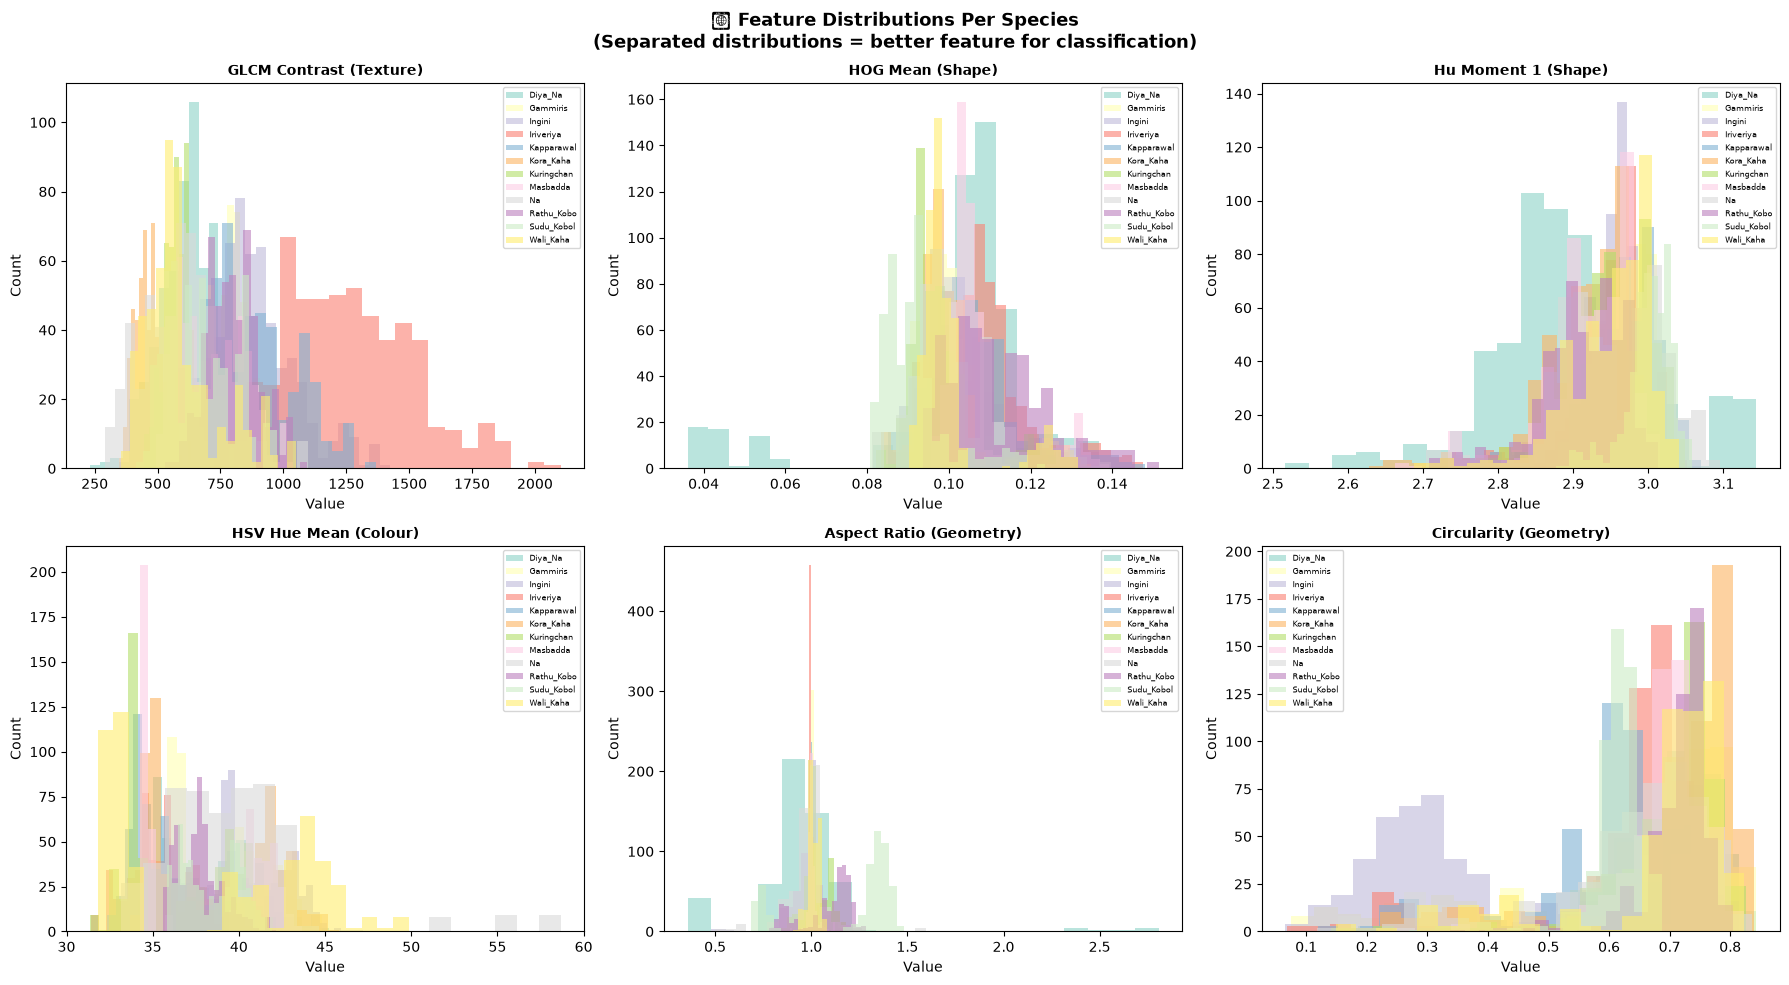

✅ Feature distribution plots saved!


In [ ]:
# Plot distribution of key features per species
plot_features = [
    ('glcm_contrast',       'GLCM Contrast (Texture)'),
    ('hog_mean',            'HOG Mean (Shape)'),
    ('hu_1',                'Hu Moment 1 (Shape)'),
    ('hsv_h_mean',          'HSV Hue Mean (Colour)'),
    ('shape_aspect_ratio',  'Aspect Ratio (Geometry)'),
    ('shape_circularity',   'Circularity (Geometry)'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    '🔬 Feature Distributions Per Species\n'
    '(Separated distributions = better feature for classification)',
    fontsize=13, fontweight='bold')

colors = plt.cm.Set3(np.linspace(0, 1, len(species_list)))

for ax, (feat, title) in zip(axes.flat, plot_features):
    for i, species in enumerate(species_list):
        vals = train_df[train_df['species']==species][feat].dropna()
        ax.hist(vals, bins=20, alpha=0.6,
                label=species[:10], color=colors[i])
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=6)

plt.tight_layout()
plt.savefig(f'{LOGS_PATH}/04_feature_distributions.png',
            bbox_inches='tight', dpi=120)
plt.show()
print('✅ Feature distribution plots saved!')

## Cell 13 — Final CSV Summary Chart

In [ ]:
print('📊 FINAL FEATURE EXTRACTION SUMMARY')
print('=' * 65)
print(f'{"CSV File":<45} {"Rows":>8} {"Columns":>8}')
print('-' * 65)

for fname in [
    'species_id_train_features.csv',
    'species_id_test_features.csv',
    'species_id_test_labels.csv'
]:
    fpath = os.path.join(CSV_PATH, fname)
    if os.path.exists(fpath):
        df = pd.read_csv(fpath)
        print(f'{fname:<45} {df.shape[0]:>8} {df.shape[1]:>8}')
    else:
        print(f'{fname:<45} {"NOT FOUND":>8}')

print('=' * 65)
print()
print('📁 CSV files location:')
print(f'   {CSV_PATH}/')
print()
print('   species_id_train_features.csv  ← WITH labels  → train model')
print('   species_id_test_features.csv   ← NO labels    → model predicts')
print('   species_id_test_labels.csv     ← TRUE labels  → check accuracy')
print()
print('📋 Next step: Run 05_Classification.ipynb')
print(f'   Input: {CSV_PATH}/species_id_train_features.csv')